# Tutorial 9 — Several suppliers, one quality measure

## 1. Problem / context

Impurity levels are measured for three resins (`resin_impurities.xlsx`). Radar-scope filters are compared on intensity (`scope_filter_intensity.xlsx`). With three or more groups, many pairwise $t$-tests inflate the type I error. One-way ANOVA tests a global null; Tukey HSD then looks at pairs.

Boxplots were taught in Session 01. Here they **motivate** ANOVA; they are not a new plot type.

## 2. Core theory

$$
H_0:\mu_1=\mu_2=\cdots=\mu_k
\quad\text{versus}\quad
H_1:\text{at least one mean differs}.
$$

The $F$-statistic compares **between-group** variation with **within-group** variation. Assumptions: independent observations, approximately normal groups, similar variances.

A significant $F$ does not name the pairs. **Tukey HSD** controls the family-wise error among pairwise mean comparisons.

## 3. From mathematics to Python

| Step | Tool |
| --- | --- |
| Boxplot | `df.boxplot(column=..., by=...)` |
| ANOVA (SciPy) | `f_oneway(*groups)` |
| ANOVA table | `statsmodels.formula.api.ols` + `anova_lm` |
| Tukey | `statsmodels.stats.multicomp.pairwise_tukeyhsd` |

## 4. Python implementation


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import f_oneway
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

candidates = [Path("data"), Path("../data")]
DATA = next(p for p in candidates if p.exists())
df = pd.read_excel(DATA / "resin_impurities.xlsx")
df.head()


,resin,impurity
0,I,0.046
1,I,0.025
2,I,0.014
3,I,0.017
4,I,0.043


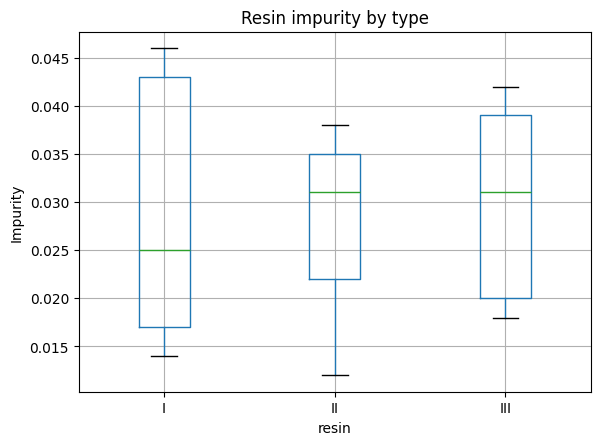

F_onewayResult(statistic=np.float64(0.048736865638274084), pvalue=np.float64(0.9526192424767927))
            sum_sq    df         F    PR(>F)
C(resin)  0.000015   2.0  0.048737  0.952619
Residual  0.001789  12.0       NaN       NaN


Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     I     II  -0.0014 0.9821  -0.022 0.0192  False
     I    III    0.001 0.9908 -0.0196 0.0216  False
    II    III   0.0024 0.9484 -0.0182  0.023  False
---------------------------------------------------


In [2]:
df.boxplot(column="impurity", by="resin")
plt.suptitle("")
plt.ylabel("Impurity")
plt.title("Resin impurity by type")
plt.show()

groups = [g["impurity"].to_numpy() for _, g in df.groupby("resin")]
print(f_oneway(*groups))

model = ols("impurity ~ C(resin)", data=df).fit()
print(anova_lm(model, typ=2))
print(pairwise_tukeyhsd(df["impurity"], df["resin"], alpha=0.05))


In [3]:
scope = pd.read_excel(DATA / "scope_filter_intensity.xlsx")
print(f_oneway(*[g["intensity"].to_numpy() for _, g in scope.groupby("filter")]))


F_onewayResult(statistic=np.float64(0.32000088294373435), pvalue=np.float64(0.7274443940901911))


## 5. Interpretation

Read the ANOVA table: large $F$ and small $p$ mean the group means are not all compatible with a single common mean, given the within-group noise. Then read Tukey: which pairs have confidence intervals for the difference that exclude zero? State the conclusion in terms of resin types or filters, not only “ANOVA was significant”.

## 6. Common mistakes / things to notice

- Six uncorrected $t$-tests among four groups.
- Stopping after a significant $F$ without pairwise follow-up when the question is “which supplier?”.
- Two-way ANOVA (not in STA1).

## 7. Short worked example

If Tukey finds only resin I versus III different, a correct engineering sentence is: “We have evidence of a mean impurity difference between I and III; II is not distinguished from the others at 5% family-wise error.”

**Conclusion in one sentence:** Use one-way ANOVA to protect against extra false positives when several groups are compared, then Tukey to locate the pairs, with boxplots from Session 01 as the visual starting point.
